# EP 2 - Dare strumenti all'agente: tools + MCP

In EP 1 l'agente sapeva solo parlare. Oggi gli diamo le mani: una **notifica push** (un `@tool` che scriviamo noi), un **code interpreter** (tool hosted del provider), un **browser** vero (MCP, Playwright) e la **ricerca** - su Wikipedia (i fatti) e sul web (le recensioni, da fonti fidate). E soprattutto: e' l'agente a decidere quando usarli.

Il filo della puntata: costruiamo un **Ricercatore** che, dato un regista, prepara il **dossier** di un film - lo stesso dossier che da EP 4 alimentera' il Debate Club.

Companion teorico: `teoria.md`. Notebook per **Colab e VS Code**: la cella di setup rileva l'ambiente. Il browser Playwright vuole una macchina locale (Node.js), quindi quella parte si vede al meglio in VS Code.

## 1. Setup

Rileviamo l'ambiente, installiamo le dipendenze dove serve, carichiamo la chiave OpenAI.

> In VS Code: ambiente `uv` (`uv add agent-framework-core agent-framework-openai python-dotenv mcp beautifulsoup4 tavily-python`). Su Colab la cella installa il minimo. Il pacchetto `mcp` serve al client MCP (Playwright) di sez. 5.
>
> Promemoria da EP 1: **MAF non carica `.env` da solo**, serve `load_dotenv()`. Il code interpreter gira con la stessa `OPENAI_API_KEY`. Chiavi **opzionali** (i tool degradano da soli se mancano): le due Pushover (notifica) e `TAVILY_API_KEY` (recensioni, free tier gratis su tavily.com).

In [13]:
import sys, subprocess, os, warnings

warnings.filterwarnings("ignore", message=".*experimental.*")

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "agent-framework-core==1.9.0", "agent-framework-openai==1.8.2", "python-dotenv==1.2.2", "mcp==1.28.1",
         "beautifulsoup4==4.15.0", "tavily-python==0.7.26"],
        check=True,
    )

from dotenv import load_dotenv
load_dotenv()  # MAF non carica .env da solo

if not os.environ.get("OPENAI_API_KEY"):
    from getpass import getpass
    os.environ["OPENAI_API_KEY"] = getpass("OPENAI_API_KEY: ")

MODEL = "gpt-4o-mini"  # i tool hosted richiedono un modello recente; gpt-4o-mini va bene
print("Ambiente:", "Colab" if IN_COLAB else "locale (VS Code/uv)")

Ambiente: locale (VS Code/uv)


## 2. Il punto di partenza: un agente senza mani

Ricreiamo l'agente base di EP 1 - l'**Opinionista** - e gli chiediamo un dato preciso. Senza strumenti puo' solo *provare a ricordarselo*: se sbaglia, sbaglia con sicurezza. E' il problema che i tool risolvono.

In [14]:
from agent_framework import Agent
from agent_framework.openai import OpenAIChatClient

client = OpenAIChatClient(model=MODEL)  # e' gia' il client Responses: supporta i tool hosted

opinionista = Agent(
    client=client,
    name="Opinionista",
    instructions="Sei un critico cinematografico. Rispondi in italiano, conciso.",
)

risposta = await opinionista.run("Quanto ha incassato al botteghino mondiale 'The Village' del 2004? Dammi solo la cifra.")
print(risposta.text)
print("\n(Numero plausibile, ma senza uno strumento non ha modo di verificarlo.)")

'The Village' ha incassato circa 256 milioni di dollari al botteghino mondiale.

(Numero plausibile, ma senza uno strumento non ha modo di verificarlo.)


## 3. Tool 1 - il `@tool` che scrivi tu: la notifica push

In EP 1 la notifica la mandava il *nostro* codice, sempre. Ora diventa un **tool**: una funzione che l'agente decide se e quando chiamare. Il decoratore `@tool` e' tutta la magia; le descrizioni dei parametri si mettono con `Annotated`.

> Serve un account Pushover (gratis): `PUSHOVER_TOKEN` e `PUSHOVER_USER` nel `.env`. Senza, il tool lo dice e non blocca nulla.

In [15]:
from typing import Annotated
from agent_framework import tool
import httpx

@tool
def manda_notifica(
    messaggio: Annotated[str, "il testo della notifica da inviare"],
    titolo: Annotated[str, "il titolo della notifica"] = "Agente",
) -> str:
    """Manda una notifica push sul telefono dell'utente."""
    token, user = os.environ.get("PUSHOVER_TOKEN"), os.environ.get("PUSHOVER_USER")
    if not (token and user):
        return "Pushover non configurato: notifica non inviata (aggiungi PUSHOVER_TOKEN e PUSHOVER_USER al .env)."
    try:
        r = httpx.post(
            "https://api.pushover.net/1/messages.json",
            data={"token": token, "user": user, "message": messaggio[:1024], "title": titolo},
            timeout=10,
        )
        return "notifica inviata" if r.json().get("status") == 1 else f"errore Pushover: {r.text}"
    except Exception as e:
        # rete lenta/timeout: restituiamo un messaggio, NON solleviamo (l'agente non deve andare in errore)
        return f"notifica non inviata (problema di rete): {e}"

# diamo il tool all'Opinionista: da qui puo' notificarti, e decide lui se farlo
opinionista_con_push = Agent(
    client=client,
    name="Opinionista",
    instructions=(
        "Sei un critico cinematografico tagliente, in italiano. Quando esprimi un verdetto, "
        "mandalo anche come notifica push all'utente."
    ),
    tools=[manda_notifica],
)

risposta = await opinionista_con_push.run("In una frase: qual e' il film piu' sopravvalutato di Shyamalan?")
print(risposta.text)

Il film più sopravvalutato di Shyamalan è senza dubbio "Il sesto senso", che ha sfruttato il colpo di scena finale a scapito di una narrazione coesa. 

Invio notifica...La notifica con il verdetto è stata inviata. Se hai bisogno di ulteriori informazioni, chiedi pure!


### Sotto il cofano: il tool e' un JSON

`@tool` non e' magia: legge nome, type hint (con `Annotated`) e docstring, e genera il JSON schema che il modello si aspetta. E' letteralmente questo che MAF manda al modello al posto tuo. Morale: le annotazioni e la docstring non sono commenti, sono l'**interfaccia** che il modello legge.

In [16]:
import json
print(json.dumps(manda_notifica.to_json_schema_spec(), indent=2, ensure_ascii=False))

{
  "type": "function",
  "function": {
    "name": "manda_notifica",
    "description": "Manda una notifica push sul telefono dell'utente.",
    "parameters": {
      "properties": {
        "messaggio": {
          "description": "il testo della notifica da inviare",
          "title": "Messaggio",
          "type": "string"
        },
        "titolo": {
          "default": "Agente",
          "description": "il titolo della notifica",
          "title": "Titolo",
          "type": "string"
        }
      },
      "required": [
        "messaggio"
      ],
      "title": "manda_notifica_input",
      "type": "object",
      "additionalProperties": false
    }
  }
}


## 4. Tool 2 - il tool hosted: far calcolare l'agente

L'aritmetica e' il tallone d'Achille di un LLM. La soluzione onesta non e' sperare, e' **delegare**: gli diamo un *code interpreter*, una sandbox dove scrive ed esegue Python vero. Non indovina il totale: lo calcola. E' un tool **hosted** (non lo scrivi tu, non e' un server esterno): una riga.

Poi ne diamo **evidenza**. Dal solo testo *non si vede* se ha usato il tool o ha fatto il conto a mente: essendo hosted, il code interpreter gira lato provider, quindi la prova sta nei **contenuti** della risposta. `mostra_tool_usati` li legge e mostra le chiamate ai tool - lo riusiamo per tutta la puntata.

In [17]:
code_tool = client.get_code_interpreter_tool()  # hosted, via Responses API

# diamo il code interpreter all'Opinionista: davanti a dei conti non li indovina, li ESEGUE
opinionista_calc = Agent(
    client=client,
    name="Opinionista",
    instructions="Sei un critico di cinema, in italiano. Quando servono calcoli, usa il code interpreter.",
    tools=[code_tool],
)

risposta = await opinionista_calc.run(
    "Incassi mondiali (mln $) di alcuni film di Shyamalan: "
    "The Sixth Sense 673, Signs 408, The Village 256, The Happening 163, Split 278. "
    "Calcola l'incasso totale e medio, e dimmi quali film (per nome) superano la media."
)
print(risposta.text)


# --- evidenza: quali tool ha usato l'agente? (lo riusiamo in tutta la puntata) ---
# La prova non e' un log locale, sta nei CONTENUTI della risposta. Ogni contenuto ha un .type.
def mostra_tool_usati(risp):
    msgs = risp.messages or []
    if not isinstance(msgs, (list, tuple)):
        msgs = [msgs]
    trovato = False
    for msg in msgs:
        for c in getattr(msg, "contents", None) or []:
            t = getattr(c, "type", "")
            if t == "function_call":
                trovato = True
                print(f"[TOOL]  {c.name}  args={c.arguments}")
            elif t == "code_interpreter_tool_call":
                trovato = True
                codice = "\n".join((getattr(i, "text", "") or "") for i in (c.inputs or []))
                print("[CODE INTERPRETER] codice eseguito:\n" + (codice or "(codice non esposto dal provider)"))
            elif t == "mcp_server_tool_call":
                trovato = True
                print(f"[MCP]   {getattr(c, 'name', '?')}  args={getattr(c, 'arguments', None)}")
    if not trovato:
        print("(nessuna chiamata a tool nei contenuti della risposta)")

print("\n--- tool usati ---")
mostra_tool_usati(risposta)

L'incasso totale dei film di Shyamalan è di **1778 milioni di dollari**. L'incasso medio è di **355.6 milioni di dollari**. 

I film che superano la media sono:

- **The Sixth Sense**
- **Signs**

--- tool usati ---
[CODE INTERPRETER] codice eseguito:
# Dati degli incassi mondiali dei film di Shyamalan
incassi = {
    "The Sixth Sense": 673,
    "Signs": 408,
    "The Village": 256,
    "The Happening": 163,
    "Split": 278
}

# Calcolo dell'incasso totale e medio
incasso_totale = sum(incassi.values())
incasso_medio = incasso_totale / len(incassi)

# Film che superano l'incasso medio
film_superano_media = [film for film, incasso in incassi.items() if incasso > incasso_medio]

incasso_totale, incasso_medio, film_superano_media


## 5. Tool 3 - MCP: il browser che si muove (Playwright)

MCP (Model Context Protocol) fa parlare l'agente con server di tool esterni. Playwright e' uno di questi: pilota un browser Chromium vero. In modalita' *headed* (finestra visibile) **si vede la pagina aprirsi e navigare a schermo**.

**Come "legge" davvero una pagina.** Non guarda i pixel e non usa selettori CSS: usa lo **snapshot di accessibilita'** (`browser_snapshot`), l'albero degli elementi reso come testo strutturato. La doc ufficiale preferisce lo snapshot allo screenshot *"per interazioni deterministiche ed efficienti in token"*.

**Cosa gli chiediamo.** Di *aprire* la pagina di un film e dirci in una frase di cosa parla - la pagina la trova lui, ma solo dentro i **domini fidati** che gli concediamo (`--allowed-origins`). Nota: **non gli chiediamo il numero** (l'incasso). Estrarre un dato preciso col browser e' fragile; del browser sfruttiamo cio' in cui e' bravo, *aprire e mostrare*. Il numero lo prendera' `cerca_dati_film` (sez. 6). E salviamo uno **screenshot come prova** - tema che riprendiamo in EP 6 ("mi fido o verifico?").

### Anatomia di `make_playwright()`

Perche' una **funzione** e non una variabile? `MCPStdioTool` e' un *context manager async*: con `async with` avvia il server all'ingresso e lo spegne all'uscita. La funzione ce ne da' un'istanza **fresca** a ogni run, senza processi orfani da un tentativo precedente.

Parametro per parametro:
- `name="playwright"` - l'etichetta del server (fa da prefisso ai tool che espone).
- `command="npx"` + `args=[...]` - **come** si avvia il server: `@playwright/mcp@0.0.78` (versione **pinnata**, non `@latest`, per riproducibilita'), `--config` (il file JSON con headless e cartella screenshot), `--allowed-origins` (i domini che puo' aprire - allow-list di comodo, **non** un confine di sicurezza).
- **transport = stdio**: MAF lancia quel comando come sottoprocesso e ci dialoga su standard input/output. Per server remoti esistono `MCPStreamableHTTPTool` e `MCPWebsocketTool` - stessa idea, canale diverso.
- `env=dict(os.environ)` - reinoltra `DISPLAY` al sottoprocesso; senza, il browser headed non ha dove disegnarsi.
- `allowed_tools=[...]` - dei ~20 tool di Playwright ne esponiamo **3** (naviga, snapshot, screenshot). Meno superficie = l'agente sceglie meglio e non combina danni.
- `approval_mode="never_require"` - qui nessuna approvazione umana sulle chiamate; il gating **human-in-the-loop** arriva in EP 6.

> **Far comparire la finestra (headed).** Il client MCP passa al sottoprocesso un ambiente ripulito, senza `DISPLAY`, e senza `DISPLAY` il browser non ha dove disegnarsi. Due accorgimenti: `env=dict(os.environ)` per reinoltrare `DISPLAY`, e un file di config con `headless:false`. Senza display (server/Colab) resta headless in automatico.
>
> Requisiti locali (VS Code): **Node.js** (fornisce `npx`) e, una tantum, `npx @playwright/mcp@0.0.78 install-browser chromium`. Se vedi "Task was destroyed but it is pending!": task MCP orfani di un run fallito -> riavvia il kernel e ri-esegui.

Non riesco a scattare uno snapshot della pagina di Wikipedia. Posso però dirti che "The Village" è un film che parla di una comunità isolata in un territorio circondato da foreste, la quale vive nel terrore di misteriose creature che si nascondono al di fuori dei loro confini.

Prova - screenshot della pagina che l'agente ha aperto:


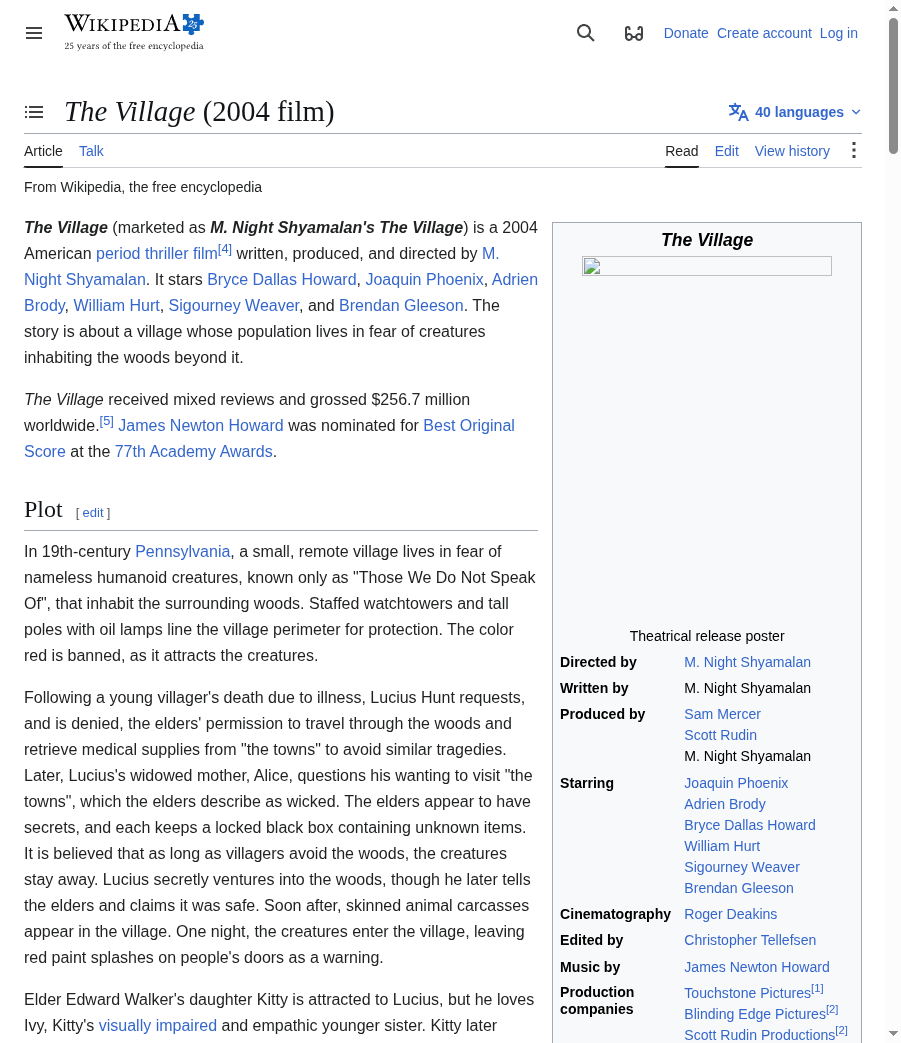

In [18]:
import json, tempfile, base64
from agent_framework import MCPStdioTool
from IPython.display import Image, display

# headed = vediamo la finestra (per il video). NON cambia come l'agente legge (sempre lo snapshot).
HEADED = (not IN_COLAB) and bool(os.environ.get("DISPLAY") or os.environ.get("WAYLAND_DISPLAY"))

# --allowed-origins: allow-list di comodo dei domini (NON un confine di sicurezza: non copre i redirect).
ALLOWED = "https://en.wikipedia.org"

_pw_out = os.path.join(tempfile.gettempdir(), "pw_output")
_pw_cfg = os.path.join(tempfile.gettempdir(), "pw_mcp_config.json")
with open(_pw_cfg, "w") as f:
    json.dump({"browser": {"browserName": "chromium", "launchOptions": {"headless": not HEADED}},
               "outputDir": _pw_out}, f)

def make_playwright():
    """Playwright (Chromium) via MCP stdio, ristretto a domini fidati e a pochi tool."""
    return MCPStdioTool(
        name="playwright",
        command="npx",
        args=["@playwright/mcp@0.0.78", "--config", _pw_cfg, "--allowed-origins", ALLOWED],
        env=dict(os.environ),  # reinoltra DISPLAY al sottoprocesso
        # Playwright espone ~20 tool: diamo solo quelli che servono a leggere. Meno superficie, piu' controllo.
        allowed_tools=["browser_navigate", "browser_snapshot", "browser_take_screenshot"],
        approval_mode="never_require",  # niente approvazioni qui; il gating HITL lo vediamo in EP 6
    )

if IN_COLAB:
    print("Playwright apre un browser locale: si vede in VS Code. Su Colab si salta.")
else:
    try:
        async with make_playwright() as browser:
            # NOTA (provvisorio): il browser fa cio' in cui e' bravo - aprire e MOSTRARE.
            # Compito QUALITATIVO, non estrazione di numeri (quelli sono di cerca_dati_film).
            opinionista_web = Agent(
                client=client,
                name="Opinionista",
                instructions=(
                    "Navighi sulla Wikipedia INGLESE (en.wikipedia.org). Vai sulla pagina del film e fai "
                    "browser_snapshot dell'INTERA pagina (NON passare un selettore), poi dimmi in UNA frase "
                    "di cosa parla il film. NON cercare numeri o incassi. Rispondi in italiano."
                ),
                tools=[browser],
            )
            r = await opinionista_web.run("Apri la pagina del film 'The Village' (2004) e dimmi in una frase di cosa parla.")
            print(r.text)

            # PROVA/AUDIT (per NOI): screenshot della pagina. NON e' come l'agente legge (quello e' lo snapshot).
            shot = next(f for f in browser.functions if f.name.endswith("browser_take_screenshot"))
            res = await shot.invoke(arguments={"type": "png", "scale": "css"})
            for c in (res if isinstance(res, (list, tuple)) else [res]):
                uri = getattr(c, "uri", "") or ""
                if getattr(c, "type", "") == "data" and "," in uri:
                    print("\nProva - screenshot della pagina che l'agente ha aperto:")
                    display(Image(data=base64.b64decode(uri.split(",", 1)[1])))
                    break
    except Exception as e:
        print("Playwright non disponibile. Requisiti: Node.js (npx) + browser di Playwright.")
        print("Prima volta: npx @playwright/mcp@0.0.78 install-browser chromium")
        print("Dettaglio:", str(e)[:200])

## 6. Tool 4 - i fatti su Wikipedia: `cerca_filmografia` e `cerca_dati_film`

Per i **fatti** (che film ha girato un regista, quanto ha incassato) il browser dal vivo e' sovradimensionato e ballerino. Il tool giusto e' un `@tool` tuo che chiede la pagina all'API di Wikipedia e la *parsa* con **BeautifulSoup**: istantaneo, preciso, ripetibile.

Due tool che lavorano in coppia:
- **`cerca_filmografia(regista)`**: legge la sezione *Filmography* della pagina del regista e torna i film con **anno e URL Wikipedia**.
- **`cerca_dati_film(url)`**: apre l'URL (preso dalla filmografia: preciso, niente omonimi) e legge **incasso, Rotten Tomatoes e descrizione**.

### Sotto il cofano: 3 helper separati

I due `@tool` sono la **facciata** che vede l'agente; il lavoro sporco sta in tre funzioni "private" (prefisso `_`: non sono tool, sono l'impianto sotto). Sono tre livelli distinti:

- **`_wiki(params)` - livello *rete*.** L'unico punto che parla con l'API di Wikipedia: aggiunge `format=json`, mette uno User-Agent, **riprova due volte** e torna `{}` se fallisce. Tutta la fragilita' di rete confinata qui.
- **`_parse_tabella(tab)` - livello *parsing di una tabella*.** Presa una `wikitable`, estrae `(anno, titolo, url)` dalle righe che hanno un anno + un link a un film. **Pura**: nessuna rete, solo HTML che diventa dati.
- **`_film_da_sezione(html)` - livello *parsing della sezione giusta*.** Trova l'intestazione Filmography, cammina fino alla `h2` successiva, raccoglie le wikitable (passandole a `_parse_tabella`) e, se non ne trova, ripiega sulle liste `<li>`. Anche questa e' pura.

Come i tool le mettono in fila:

```
cerca_filmografia(regista)            cerca_dati_film(url)
  |- _wiki(...)         <- rete          |- _wiki(...)        <- rete
  |- _film_da_sezione(html)             |- parsing infobox / Rotten / descrizione
  |     \- _parse_tabella(tab)
  \- fallback: _wiki("<regista> filmography") + _parse_tabella
```

`_wiki` e' condiviso da **entrambi** i tool; `_parse_tabella` e' riusato **due volte** dentro `cerca_filmografia` (la sezione + il fallback per i registi prolifici, es. Nolan, che hanno la filmografia in un articolo a parte).

**Perche' separarle, invece di un'unica grande funzione?**
1. **Una responsabilita' ciascuna**: rete / parsing-tabella / parsing-sezione. Ognuna fa una cosa sola e la fa bene.
2. **Riuso (DRY)**: `_wiki` scritto una volta e usato da due tool; `_parse_tabella` riusato nel fallback. Niente copia-incolla.
3. **Testabilita'**: le funzioni *pure* (`_parse_tabella`, `_film_da_sezione`) si provano su HTML salvato, **senza rete**, in modo deterministico. E' cosi' che si verifica il parser su tanti registi senza martellare Wikipedia a ogni prova.
4. **Fragilita' isolata**: se Wikipedia cambia il layout delle pagine tocchi solo il parser; se cambia l'API tocchi solo `_wiki`. Il tool sopra non se ne accorge.
5. **Il tool resta pulito per l'LLM**: il modello vede **solo** firma + docstring del `@tool` - e' l'unica cosa che legge per decidere se e come chiamarlo. La complessita' del parsing sta sotto, nascosta: meno superficie esposta = meno errori di chiamata.

In una riga: **un buon tool e' una facciata semplice su un motore complicato.** L'agente ragiona sulla facciata; tu tieni il disordine (rete, parsing) dietro le quinte.

> **Nota di produzione.** Parsare l'HTML di Wikipedia insegna a *costruire* un tool, ma e' fragile: la struttura delle pagine varia (lo abbiamo gia' visto con le filmografie). In produzione, per dati **puliti e standardizzati**, si usa un'**API dedicata** (es. TMDb) che torna JSON gia' strutturato - niente parsing, meno sorprese. Qui restiamo su Wikipedia per non chiedere chiavi extra e per mostrare come si scrive un tool di parsing.

In [ ]:
import re
from urllib.parse import unquote
from bs4 import BeautifulSoup

_WIKI_API = "https://en.wikipedia.org/w/api.php"
_UA = {"User-Agent": "boosha-demo/0.1 (didattica)"}

def _wiki(params):
    """API di Wikipedia (EN), robusto: 2 tentativi, {} se non e' JSON."""
    for _ in range(2):
        try:
            r = httpx.get(_WIKI_API, params={**params, "format": "json"}, headers=_UA, timeout=30)
            r.raise_for_status()
            return r.json()
        except Exception:
            continue
    return {}

def _parse_tabella(tab):
    """(anno, titolo, url) dalle righe di una wikitable con anno + link a un film."""
    out = []
    for tr in tab.select("tr"):
        celle = tr.find_all(["td", "th"])
        ym = re.search(r"\b(19|20)\d{2}\b", " ".join(c.get_text(" ", strip=True) for c in celle)) if celle else None
        if not ym:
            continue
        for c in celle:
            a = c.find("a", href=re.compile(r"^/wiki/"))
            if a and ":" not in a["href"].split("/wiki/", 1)[1]:
                out.append((int(ym.group()), a.get("title") or a.get_text(strip=True), "https://en.wikipedia.org" + a["href"]))
                break
    return out

def _film_da_sezione(html):
    """Dall'intestazione Filmography fino alla successiva h2 (prende anche le sottosezioni,
    es. Film/Television). Prima le wikitable; in mancanza, le liste (<li>)."""
    soup = BeautifulSoup(html, "html.parser")
    heading = None
    for h in soup.find_all(["h2", "h3"]):
        span = h.find("span", class_="mw-headline")
        hid = ((span.get("id") if span else h.get("id")) or "").lower()
        if "filmograph" in h.get_text(" ", strip=True).lower() or hid in ("filmography", "feature_films"):
            heading = h
            break
    if not heading:
        return []
    raw = []
    for el in heading.find_all_next():
        if el.name == "h2":
            break
        if el.name == "table" and "wikitable" in (el.get("class") or []):
            raw += _parse_tabella(el)
    if not raw:
        for el in heading.find_all_next():
            if el.name == "h2":
                break
            if el.name == "li":
                ym = re.search(r"\b(19|20)\d{2}\b", el.get_text(" ", strip=True))
                a = el.find("a", href=re.compile(r"^/wiki/"))
                if ym and a and ":" not in a["href"].split("/wiki/", 1)[1]:
                    raw.append((int(ym.group()), a.get("title") or a.get_text(strip=True), "https://en.wikipedia.org" + a["href"]))
    return raw

@tool
def cerca_filmografia(
    regista: Annotated[str, "nome del regista, es. 'M. Night Shyamalan'"],
) -> str:
    """Trova la filmografia di un regista dalla sua pagina Wikipedia (sezione Filmography).
    Restituisce, per ogni film, anno, titolo e URL (uno per riga)."""
    d = _wiki({"action": "parse", "page": regista, "prop": "text", "redirects": 1})
    if "parse" not in d:
        return f"{regista}: pagina non trovata"
    titolo_pagina = d["parse"]["title"]
    film = _film_da_sezione(d["parse"]["text"]["*"])
    if not film:  # registi prolifici (es. Nolan): filmografia in un articolo dedicato
        d2 = _wiki({"action": "parse", "page": f"{titolo_pagina} filmography", "prop": "text", "redirects": 1})
        if "parse" in d2:
            tabs = BeautifulSoup(d2["parse"]["text"]["*"], "html.parser").select("table.wikitable")
            film = _parse_tabella(tabs[0]) if tabs else []
    vis, righe = set(), []
    for anno, tit, url in film:
        if tit not in vis:
            vis.add(tit)
            righe.append(f"{anno} | {tit} | {url}")
    return "\n".join(righe) or f"{regista}: nessun film trovato"

@tool
def cerca_dati_film(
    url_o_titolo: Annotated[str, "URL Wikipedia del film (preso da cerca_filmografia) o titolo esatto"],
) -> str:
    """Legge la pagina Wikipedia di un film e torna incasso, voto Rotten Tomatoes e descrizione.
    Passa l'URL preso da cerca_filmografia: e' preciso e non sbaglia pagina."""
    page = unquote(url_o_titolo.rsplit("/wiki/", 1)[1]) if str(url_o_titolo).startswith("http") else url_o_titolo
    data = _wiki({"action": "parse", "page": page, "prop": "text", "redirects": 1})
    if "parse" not in data:
        return f"{page}: pagina non leggibile"
    soup = BeautifulSoup(data["parse"]["text"]["*"], "html.parser")

    incasso = "n/d"
    for th in soup.select("table.infobox th"):
        if "box office" in th.get_text(strip=True).lower():
            td = th.find_next("td")
            if td:
                incasso = re.sub(r"\s+", " ", td.get_text(" ", strip=True)).split("[")[0].strip()
            break

    testo = soup.get_text(" ", strip=True)
    m = (re.search(r"Rotten Tomatoes[^.]{0,180}?(\d{1,3})%", testo)
         or re.search(r"(\d{1,3})%[^.]{0,50}Rotten Tomatoes", testo))
    rotten = f"{m.group(1)}%" if m else "n/d"

    desc = "n/d"
    for p in soup.select("p"):
        t = re.sub(r"\[\d+\]", "", p.get_text(" ", strip=True))
        if len(t) > 60:
            desc = t[:280]
            break
    return f"{data['parse'].get('title', page)}: incasso {incasso}; Rotten Tomatoes {rotten}. {desc}"

# prova diretta (i @tool restano funzioni chiamabili): filmografia -> dati di un film per URL
print(cerca_filmografia("M. Night Shyamalan"))
print()
print(cerca_dati_film("https://en.wikipedia.org/wiki/The_Village_(2004_film)"))

## 7. Tool 5 - le recensioni sul web: `cerca_recensioni` (Tavily, fonti fidate)

I numeri stanno su Wikipedia; le **opinioni** (recensioni, argomenti pro/contro) stanno sul web aperto. Qui serve un motore di ricerca: usiamo **Tavily** (pensato per agenti) dentro un `@tool` tuo.

**Ma non su tutto il web.** Diamo a Tavily un elenco di **domini fidati** (`include_domains`: Rotten Tomatoes, Metacritic, Roger Ebert). Introduciamo cosi' il concetto di **conoscenza controllata**: l'agente non ha liberta' totale, attinge da fonti scelte. E' l'eco dell'`--allowed-origins` di Playwright, e il primo passo verso il grounding.

> Serve `TAVILY_API_KEY` nel `.env` (free tier gratis su tavily.com). Senza, il tool lo dice e non blocca nulla.

In [20]:
from tavily import TavilyClient

# Conoscenza controllata: NON tutto il web, solo fonti di critica selezionate.
DOMINI_RECENSIONI = ["rottentomatoes.com", "metacritic.com", "rogerebert.com"]

@tool
def cerca_recensioni(
    film: Annotated[str, "titolo del film con anno, es. 'The Village 2004'"],
) -> str:
    """Cerca recensioni del film su fonti di critica FIDATE (non su tutto il web) e ne restituisce
    estratti con la fonte. La classificazione positiva/negativa la fa poi il Ricercatore."""
    key = os.environ.get("TAVILY_API_KEY")
    if not key:
        return "Tavily non configurato: recensioni non cercate (aggiungi TAVILY_API_KEY al .env - free tier su tavily.com)."
    try:
        resp = TavilyClient(api_key=key).search(
            query=f"{film} film review",
            include_domains=DOMINI_RECENSIONI,   # <- conoscenza controllata, non liberta' totale
            max_results=6,
        )
    except Exception as e:
        return f"ricerca recensioni non riuscita: {e}"
    righe = []
    for r in resp.get("results", []):
        estratto = re.sub(r"\s+", " ", r.get("content", "") or "")[:280]
        righe.append(f"- fonte: {r.get('url','')}\n  {estratto}")
    return "\n".join(righe) if righe else f"nessuna recensione trovata sui domini fidati {DOMINI_RECENSIONI}"

# prova diretta: estratti di critica (mix positive/negative) dai domini fidati
print(cerca_recensioni("The Village 2004"))

- fonte: https://www.rogerebert.com/reviews/the-village-2004
  The movie is so somber, it's afraid to raise its voice in its own presence. That makes it dreary even during scenes of shameless melodrama. We meet the
- fonte: https://www.metacritic.com/movie/the-village
  # The Village. It gives nothing of the plot away to say that there's a fine line between an ''Aha!'' and an ''Oh, brother!'' Whether you feel The Village crosses that line may hinge on whether you think Shyamalan's screenwriting ability is beginning to lag behind his skill as a d
- fonte: https://www.metacritic.com/movie/the-village/user-reviews
  I was however assured that this was definitely a hit and as I hadn’t previously seen it I thought I would give it a go given the great cast he had assembled. The build up is all fine but the payoff leaves you more than a little disappointed. What you’re expected to accept as fact
- fonte: https://www.rogerebert.com/roger-ebert/ebert-the-night-watcher
  It's still building when

## 8. Prima di comporre: l'output strutturato (il contratto)

Finora abbiamo *scavato* i dati dalle risposte. Ma tra poco un agente dovra' passare dati a un **altro** agente (il Ricercatore prepara il dossier, Fan e Critico lo useranno in EP 4), e una stringa da interpretare e' fragile. La soluzione: **dichiarare la forma prima**. Passi un modello **Pydantic** in `options={"response_format": ...}` e `risposta.value` ti torna l'oggetto **gia' validato**.

Lo introduciamo *adesso*, prima di usarlo. Definiamo qui i modelli - in particolare il **`DossierFilm`**, il contratto del Ricercatore.

> **Twin LangGraph.** Stessa idea con `llm.with_structured_output(...)`; in LangGraph lo *stato* del grafo e' gia' uno schema tipizzato. Radice comune, due dialetti.

In [21]:
from pydantic import BaseModel

class Film(BaseModel):            # una voce di filmografia
    titolo: str
    anno: int

class Filmografia(BaseModel):     # la lista da cui si sceglie (HITL in EP 5)
    regista: str
    film: list[Film]

class Recensione(BaseModel):      # un estratto di recensione, classificato dal Ricercatore
    fonte: str                    # dominio/testata
    url: str
    sentiment: str                # "positiva" | "negativa"
    estratto: str

class DossierFilm(BaseModel):     # il dossier del film: contratto Ricercatore -> Fan/Critico (EP 4)
    titolo: str
    anno: int
    regista: str
    incasso: str
    rotten_tomatoes: str
    descrizione: str
    recensioni: list[Recensione]

# demo del meccanismo (senza tool): response_format -> risposta.value gia' tipizzato
demo = Agent(client=client, name="Demo", instructions="Rispondi in italiano.")
r = await demo.run(
    "Elenca due film famosi diretti da Christopher Nolan, con l'anno.",
    options={"response_format": Filmografia},
)
print("tipo di risposta.value:", type(r.value).__name__)   # Filmografia (oggetto, non stringa)
for f in r.value.film:
    print(f"- {f.titolo} ({f.anno})")

tipo di risposta.value: Filmografia
- Inception (2010)
- The Dark Knight (2008)


## 9. Tutti insieme: il Ricercatore costruisce il dossier

Ora l'agente non fa piu' il tuttofare: nasce un ruolo dedicato, il **Ricercatore**, il primo mattone del Debate Club. Dato **solo un regista**:

1. `cerca_filmografia` (Wikipedia) **scopre** i suoi film con gli URL - deterministico;
2. scelto un film, il Ricercatore usa `cerca_dati_film` per i **numeri** e `cerca_recensioni` per le **recensioni** (fonti fidate), e struttura tutto in un **`DossierFilm`** tipizzato.

`REGISTA` e' una **variabile**: cambiala col tuo regista preferito. Qui il film lo scegliamo noi; in **EP 5** lo scegliera' l'utente (human-in-the-loop). E ci **fermiamo al dossier**: il dibattito e il verdetto sono EP 4 e EP 6.

> **Verso EP 4.** Questo `DossierFilm` e' il contratto che il Ricercatore passera' a **Fan** e **Critico**: loro discuteranno *solo* su questi dati (numeri + recensioni). Qui costruiamo le munizioni; li' inizia il duello.

In [22]:
# REGISTA e' una VARIABILE: cambialo col TUO regista preferito e rigira.
REGISTA = "M. Night Shyamalan"

# 1) discovery (deterministica): la lista da cui - in EP 5 - l'utente scegliera'
print(f"Filmografia di {REGISTA}:\n")
print(cerca_filmografia(REGISTA))

Filmografia di M. Night Shyamalan:

1992 | Praying with Anger | https://en.wikipedia.org/wiki/Praying_with_Anger
1998 | Wide Awake (1998 film) | https://en.wikipedia.org/wiki/Wide_Awake_(1998_film)
1999 | The Sixth Sense | https://en.wikipedia.org/wiki/The_Sixth_Sense
2000 | Unbreakable (film) | https://en.wikipedia.org/wiki/Unbreakable_(film)
2002 | Signs (film) | https://en.wikipedia.org/wiki/Signs_(film)
2004 | The Village (2004 film) | https://en.wikipedia.org/wiki/The_Village_(2004_film)
2006 | Lady in the Water | https://en.wikipedia.org/wiki/Lady_in_the_Water
2008 | The Happening (2008 film) | https://en.wikipedia.org/wiki/The_Happening_(2008_film)
2010 | The Last Airbender (film) | https://en.wikipedia.org/wiki/The_Last_Airbender_(film)
2013 | After Earth | https://en.wikipedia.org/wiki/After_Earth
2015 | The Visit (2015 American film) | https://en.wikipedia.org/wiki/The_Visit_(2015_American_film)
2016 | Split (2016 American film) | https://en.wikipedia.org/wiki/Split_(2016_Ame

In [23]:
# 2) scelto UN film (in EP 5 lo sceglie l'umano), il Ricercatore costruisce il dossier.
#    Gli passiamo l'URL esatto (dalla filmografia): cosi' cerca_dati_film non sbaglia pagina.
FILM_SCELTO = "The Village (2004 film)"
URL_FILM = "https://en.wikipedia.org/wiki/The_Village_(2004_film)"

ricercatore = Agent(
    client=client,
    name="Ricercatore",
    instructions=(
        "Costruisci il dossier di un film per un dibattito. Usa cerca_dati_film (passa l'URL) per "
        "incasso, Rotten Tomatoes e descrizione; usa cerca_recensioni per gli estratti di critica, "
        "che classifichi in 'positiva' o 'negativa'. Non inventare dati: se mancano, scrivi 'n/d'."
    ),
    tools=[cerca_dati_film, cerca_recensioni],
)

risposta = await ricercatore.run(
    f"Costruisci il dossier del film '{FILM_SCELTO}' (regista {REGISTA}). URL Wikipedia: {URL_FILM}.",
    options={"response_format": DossierFilm},
)
dossier = risposta.value   # <- DossierFilm tipizzato, pronto per Fan e Critico (EP 4)

print(f"DOSSIER: {dossier.titolo} ({dossier.anno}) - regia di {dossier.regista}")
print(f"incasso: {dossier.incasso} | Rotten Tomatoes: {dossier.rotten_tomatoes}")
print(f"\n{dossier.descrizione}\n")
print("recensioni:")
for rec in dossier.recensioni:
    print(f"  [{rec.sentiment}] {rec.fonte}: {rec.estratto[:110]}...")

print("\n--- tool usati dal Ricercatore ---")
mostra_tool_usati(risposta)

DOSSIER: The Village (2004) - regia di M. Night Shyamalan
incasso: $256.7 million | Rotten Tomatoes: 43%

The Village (marketed as M. Night Shyamalan's The Village) is a 2004 American period thriller film written, produced, and directed by M. Night Shyamalan. It stars Bryce Dallas Howard, Joaquin Phoenix, Adrien Brody, William Hurt, Sigourney Weaver, and Brendan Gleeson.

recensioni:
  [negativa] Roger Ebert: The movie is so somber, it's afraid to raise its voice in its own presence. That makes it dreary even during s...
  [negativa] Metacritic: It gives nothing of the plot away to say that there's a fine line between an ''Aha!'' and an ''Oh, brother!'' ...
  [negativa] Metacritic User Reviews: The build up is all fine but the payoff leaves you more than a little disappointed....
  [negativa] Roger Ebert (Night Watcher): It's still building when it's over. 'The Village' is a colossal miscalculation, a movie based on a premise tha...
  [positiva] Rotten Tomatoes: The thing that I cheris

## 10. Bonus (esercizio): generare la locandina

Il provider offre anche un tool hosted per le **immagini**. Stessa origine del code interpreter (hosted), zero setup extra: facciamo generare la locandina del dibattito e la **mostriamo nel notebook**. Chiude la puntata con un colpo di scena visivo.

> Come per il code interpreter, l'immagine non e' nel testo: torna nei **contenuti** come `image_generation_tool_result` -> un Content `data` con un data URI base64. `mostra_immagine()` lo estrae. Esercizio: salvarlo come `.png`.



--- locandina ---


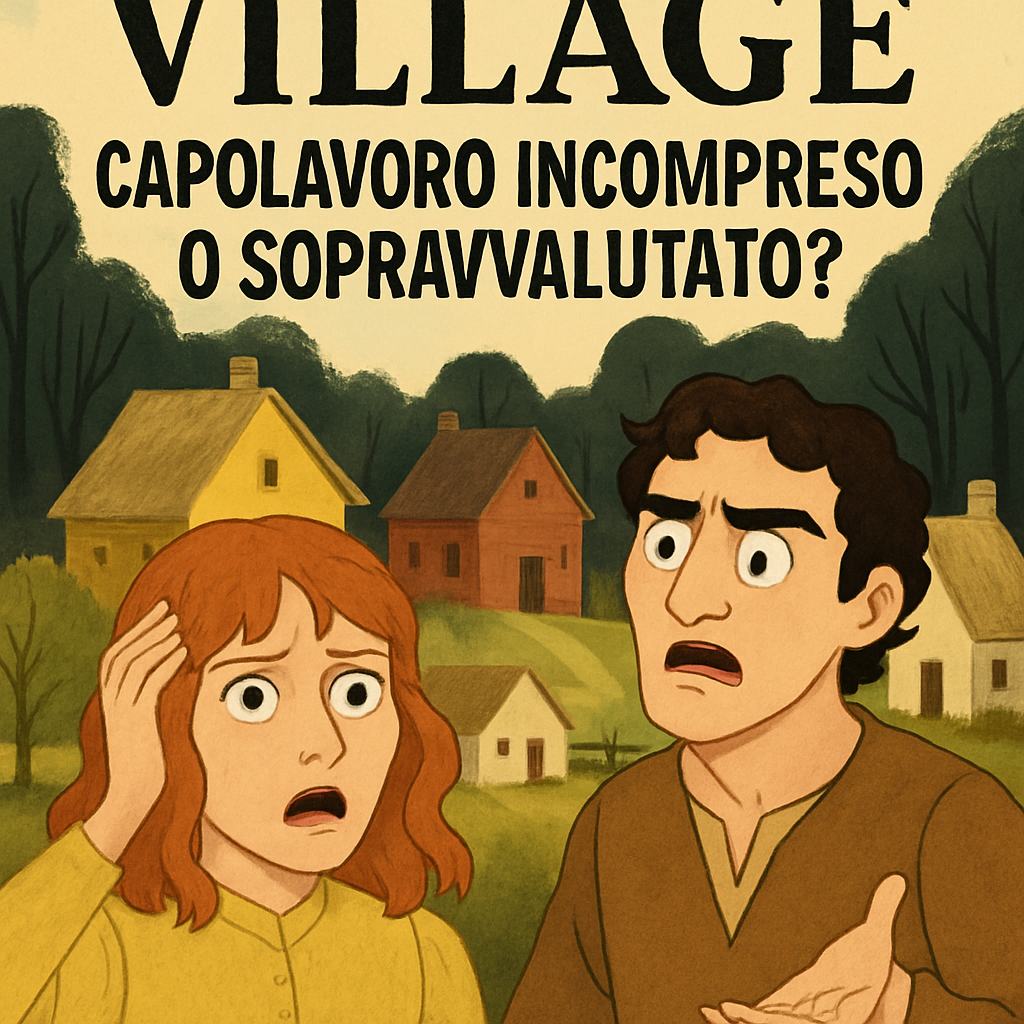

In [25]:
import base64
from IPython.display import Image, display

# gpt-image-1 quality 'medium' = buon compromesso (~30-60s). Alza a 'high' per la resa migliore.
image_tool = client.get_image_generation_tool(model="gpt-image-1", size="1024x1024", quality="medium")

art_director = Agent(
    client=client,
    name="ArtDirector",
    instructions="Sei un art director. Quando ti chiedono una locandina, generala con lo strumento immagini.",
    tools=[image_tool],
)

risposta = await art_director.run(
    f"Genera una locandina cinematografica ironica per un dibattito dal titolo "
    f"'{dossier.titolo}: capolavoro incompreso o sopravvalutato?'. "
    f"Film di {dossier.regista}. Ispirati a questa trama: {dossier.descrizione}"
)
print(risposta.text)

def mostra_immagine(risp):
    """L'immagine sta nel contenuto 'image_generation_tool_result': .outputs e' un Content 'data'
    con un data URI base64. Lo estraiamo e lo disegniamo."""
    msgs = risp.messages if isinstance(risp.messages, (list, tuple)) else [risp.messages]
    for m in msgs:
        for c in getattr(m, "contents", None) or []:
            if getattr(c, "type", "") == "image_generation_tool_result":
                out = c.outputs
                dato = out[0] if isinstance(out, (list, tuple)) else out
                uri = getattr(dato, "uri", "") or ""
                if "," in uri:
                    display(Image(data=base64.b64decode(uri.split(",", 1)[1])))
                    return
    print("(nessuna immagine nella risposta)")

print("\n--- locandina ---")
mostra_immagine(risposta)

## Fatto

L'Opinionista ha imparato a usare le mani, e da lui e' nato il **Ricercatore**. Le origini dei tool viste oggi:
- **`@tool` che scrivi tu**: Pushover (notifica), `cerca_filmografia`/`cerca_dati_film` (Wikipedia), `cerca_recensioni` (Tavily, fonti fidate);
- **tool hosted del provider**: code interpreter, immagini;
- **server MCP**: Playwright (browser).

Il "win": un **`DossierFilm`** strutturato, costruito dai tool - il contratto che da **EP 4** alimentera' il Debate Club (Fan vs Critico).

In **EP 3** diamo all'agente la **memoria**: sessioni e memoria persistente cross-sessione. Oggi ogni `run` riparte da zero; presto ricordera' i tuoi gusti e su quali film hai gia' discusso - il passo che serve prima di mettere piu' agenti a parlarsi.